# Stage 11: Supervised Rat-Space Exercise Subspace Probe

## Stage Objective

Test whether exercise exposure is encoded in the rat GeneCompass latent space at the tissue-by-cell-type level.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Block definition | Construct analyzable tissue-by-cell-type blocks with aligned embeddings and metadata. |
| 2 | Supervised probe | Fit a one-component PLS model and quantify held-out treatment discrimination. |
| 3 | Permutation inference | Estimate block-level significance and control the false discovery rate across blocks. |
| 4 | Corroboration | Compare supervised-probe results with the independent Augur random-forest analysis. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 9 rat-space embeddings, aligned metadata, and Stage 10 analysis context. |
| Primary outputs | Block-level probe statistics, corroboration tables, and the set of rat-space exercise hotspots. |

## Result Overview

The analysis evaluates 172 blocks and identifies 15 FDR-significant exercise hotspots for the Stage 12 transfer test.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [1]:
import os, pathlib
ROOT = pathlib.Path("..")
GCI  = ROOT / "data/deconvolution/genecompass_input"

files = {
    "subspace_probe.tsv":      GCI / "subspace_probe.tsv",
    "corroboration_merged.tsv":GCI / "corroboration_merged.tsv",
    "pheno_merge_test.tsv":    GCI / "pheno_merge_test.tsv",
}
for name, p in files.items():
    stat = p.stat() if p.exists() else None
    size_kb = stat.st_size / 1024 if stat else 0
    lines = sum(1 for _ in open(p)) if p.exists() else 0
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {name}: {lines} rows, {size_kb:.1f} KB")


  [OK] subspace_probe.tsv: 173 rows, 37.7 KB
  [OK] corroboration_merged.tsv: 173 rows, 27.4 KB
  [OK] pheno_merge_test.tsv: 173 rows, 10.7 KB


## Probe design and block structure

Each **block** = (tissue × cell-type) pair with ≥10 pseudo-cells.
- 10 tissues, 172 testable blocks (1 singleton block excluded).
- Each block has **n = 50** pseudo-cells (5 per animal × 10 animals; padded to 50).
- PLS-1 probe: 5-fold CV, AUC computed on OOF predictions.
- Permutation test: 1 000 label-shuffled runs per block; empirical p-value.
- Multiple testing: BH-FDR across 172 blocks → `q_sup_trained`.

**Four probe factors** tested per block:
1. `trained` — binary: trained (weeks 1/2/4/8) vs control
2. `dose(ord)` — ordinal: week 1/2/4/8 (training animals only)
3. `sex` — binary: male vs female (positive control, expected to be detectable)
4. `group` — four-class: trained 4w, trained 8w, control 4w, control 8w (omnibus)


In [2]:
import pandas as pd
GCI = "../data/deconvolution/genecompass_input"
sp = pd.read_csv(f"{GCI}/subspace_probe.tsv", sep="\t")
q_values = pd.read_csv(
    f"{GCI}/corroboration_merged.tsv",
    sep="\t",
    usecols=["tissue", "cell_type", "q_sup_trained"],
)
sp = sp.merge(q_values, on=["tissue", "cell_type"], how="left", validate="one_to_one")
if sp["q_sup_trained"].isna().any():
    raise ValueError("Missing adjusted P values after merging Stage 11 result tables")

# q_sup_trained hotspot flag
sp["is_hotspot"] = sp["q_sup_trained"] < 0.05

summary = sp.groupby("tissue").agg(
    n_blocks         = ("tissue", "size"),
    n_hotspot        = ("is_hotspot", "sum"),
    median_sup_auc   = ("sup_trained_auc", "median"),
    max_sup_auc      = ("sup_trained_auc", "max"),
    median_sex_auc   = ("sup_sex_auc", "median"),
    median_dose_rho  = ("sup_dose_rho", "median"),
).reset_index()
summary["hotspot_pct"] = (summary["n_hotspot"] / summary["n_blocks"] * 100).round(1)
pd.set_option("display.width", 120)
print("=== per-tissue probe summary ===")
print(summary.to_string(index=False))
print(f"\nTOTAL: {len(sp)} blocks | {sp['is_hotspot'].sum()} hotspots (q_sup_trained<0.05)")
print(f"Global sup_trained_auc: median={sp['sup_trained_auc'].median():.3f}, "
      f"max={sp['sup_trained_auc'].max():.3f}")


=== per-tissue probe summary ===
tissue  n_blocks  n_hotspot  median_sup_auc  max_sup_auc  median_sex_auc  median_dose_rho  hotspot_pct
   bat         6          0          0.4715        0.510          0.6585           0.1585          0.0
 blood        14          7          0.7975        0.858          0.7695           0.2680         50.0
cortex        11          0          0.5070        0.672          0.6160          -0.0430          0.0
 heart        16          2          0.5840        0.858          0.9640           0.1765         12.5
hippoc        18          0          0.4975        0.690          0.5690          -0.1485          0.0
hypoth        13          0          0.6230        0.755          0.6210          -0.0590          0.0
kidney        17          1          0.5420        0.828          0.9470          -0.0560          5.9
 liver         6          0          0.5340        0.692          1.0000           0.2455          0.0
  lung        28          2          0.5

## FIG 1 — Supervised trained AUC distribution across 172 blocks

The histogram shows all 185 block-level `sup_trained_auc` values.
Blocks with `q_sup_trained < 0.05` (exercise hotspots) are shaded darker.
The KDE curve overlaid on the AUC axis shows the shape of the full distribution.
The inset rug on the dose axis shows the distribution of `sup_dose_rho`.


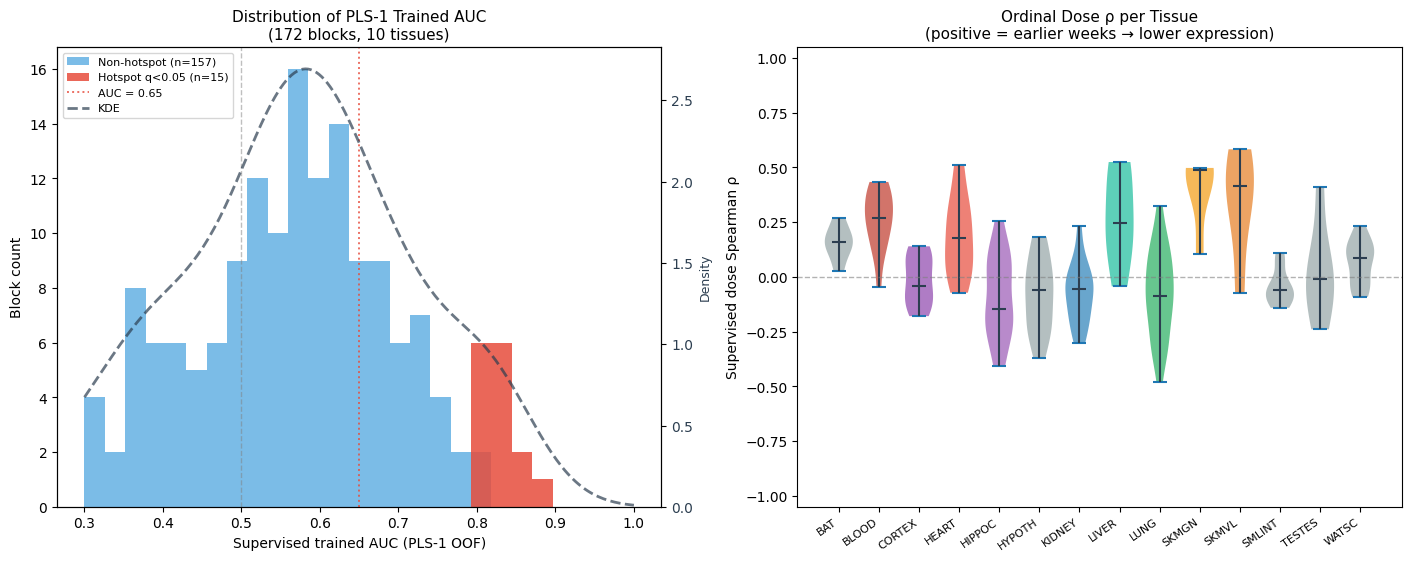

hotspot count: 15 / 172
sup_trained_auc: median=0.576, max=0.893


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

GCI = "../data/deconvolution/genecompass_input"
sp = pd.read_csv(f"{GCI}/subspace_probe.tsv", sep="\t")
q_values = pd.read_csv(
    f"{GCI}/corroboration_merged.tsv",
    sep="\t",
    usecols=["tissue", "cell_type", "q_sup_trained"],
)
sp = sp.merge(q_values, on=["tissue", "cell_type"], how="left", validate="one_to_one")
if sp["q_sup_trained"].isna().any():
    raise ValueError("Missing adjusted P values after merging Stage 11 result tables")
sp["is_hotspot"] = sp["q_sup_trained"] < 0.05

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: AUC histogram
ax = axes[0]
hot = sp[sp["is_hotspot"]]["sup_trained_auc"].values
non = sp[~sp["is_hotspot"]]["sup_trained_auc"].values
bins = np.linspace(0.3, 1.0, 28)
ax.hist(non, bins=bins, color="#3498DB", alpha=0.65, label=f"Non-hotspot (n={len(non)})")
ax.hist(hot, bins=bins, color="#E74C3C", alpha=0.85, label=f"Hotspot q<0.05 (n={len(hot)})")

# KDE overlay
all_auc = sp["sup_trained_auc"].values
kde = gaussian_kde(all_auc, bw_method=0.35)
xs  = np.linspace(0.3, 1.0, 200)
ys  = kde(xs)
ax2 = ax.twinx()
ax2.plot(xs, ys, color="#2C3E50", lw=2.0, ls="--", alpha=0.7, label="KDE")
ax2.set_ylabel("Density", fontsize=9, color="#2C3E50")
ax2.tick_params(axis="y", labelcolor="#2C3E50")
ax2.set_ylim(0)

ax.axvline(0.65, color="#E74C3C", lw=1.4, ls=":", alpha=0.8, label="AUC = 0.65")
ax.axvline(0.5,  color="gray",    lw=1.0, ls="--", alpha=0.5)
ax.set_xlabel("Supervised trained AUC (PLS-1 OOF)", fontsize=10)
ax.set_ylabel("Block count", fontsize=10)
ax.set_title("Distribution of PLS-1 Trained AUC\n(172 blocks, 10 tissues)", fontsize=11)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper left")

# Right: dose rho distribution by tissue
ax = axes[1]
tissues = sorted(sp["tissue"].unique())
dose_data = [sp[sp["tissue"]==t]["sup_dose_rho"].values for t in tissues]
parts = ax.violinplot(dose_data, positions=range(len(tissues)), showmedians=True, widths=0.7)
for i, (body, t) in enumerate(zip(parts["bodies"], tissues)):
    body.set_facecolor(PALETTE.get(t, "#95A5A6"))
    body.set_alpha(0.7)
parts["cmedians"].set_color("#2C3E50")
parts["cbars"].set_color("#2C3E50")
ax.axhline(0, color="gray", lw=1.0, ls="--", alpha=0.6)
ax.set_xticks(range(len(tissues)))
ax.set_xticklabels([t.upper() for t in tissues], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Supervised dose Spearman ρ", fontsize=10)
ax.set_title("Ordinal Dose ρ per Tissue\n(positive = earlier weeks → lower expression)", fontsize=11)
ax.set_ylim(-1.05, 1.05)

plt.show()
print(f"hotspot count: {sp['is_hotspot'].sum()} / {len(sp)}")
print(f"sup_trained_auc: median={sp['sup_trained_auc'].median():.3f}, max={sp['sup_trained_auc'].max():.3f}")


## Supervised probe vs global (omnibus) detection

The global trace η² (`glob_trained`) is a permutation-tested MANOVA-like statistic that
tests whether any linear combination of dimensions separates trained vs control.
It is a less powerful estimator than PLS-1 because it treats all 768 dimensions equally
and does not learn the separation axis.

Comparing `glob_trained` to `sup_trained_auc` reveals the **power gain from supervision**:
blocks where the global measure is near zero but the supervised AUC is high indicate that
the exercise signal lives in a low-variance but informative subspace (a hallmark of transformer
CLS tokens where global variance is dominated by cell-type identity, not treatment).


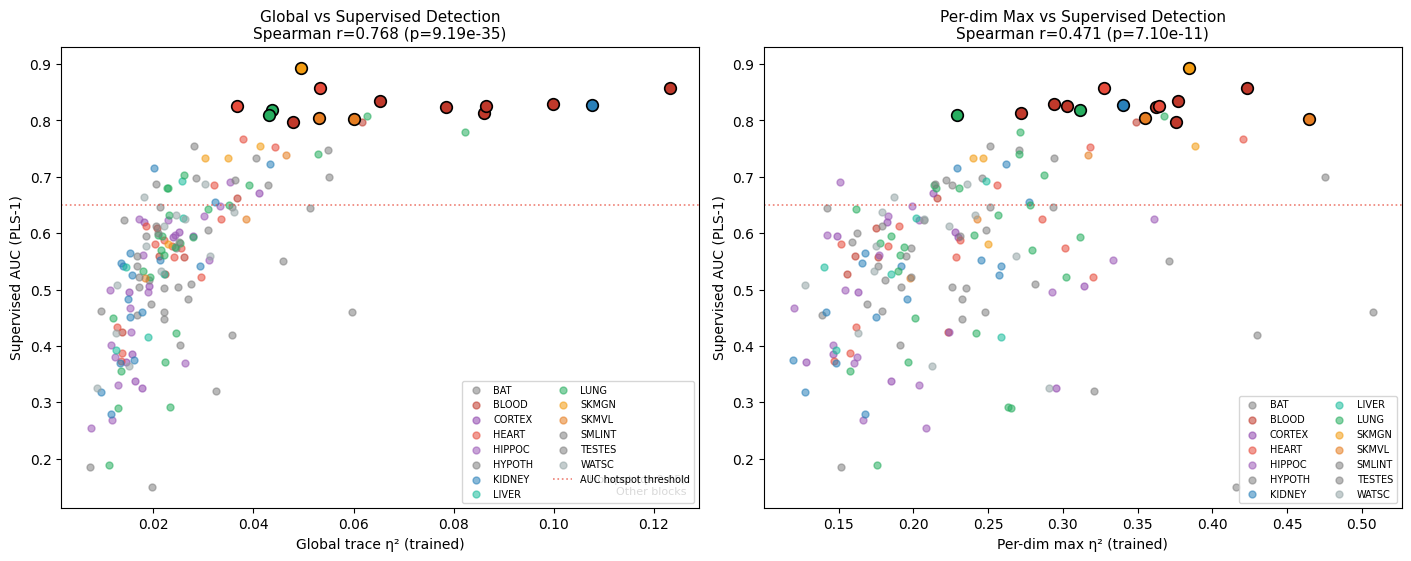

glob vs sup: r=0.768  pdmax vs sup: r=0.471


In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

GCI = "../data/deconvolution/genecompass_input"
sp = pd.read_csv(f"{GCI}/subspace_probe.tsv", sep="\t")
q_values = pd.read_csv(
    f"{GCI}/corroboration_merged.tsv",
    sep="\t",
    usecols=["tissue", "cell_type", "q_sup_trained"],
)
sp = sp.merge(q_values, on=["tissue", "cell_type"], how="left", validate="one_to_one")
if sp["q_sup_trained"].isna().any():
    raise ValueError("Missing adjusted P values after merging Stage 11 result tables")
sp["is_hotspot"] = sp["q_sup_trained"] < 0.05

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: glob_trained vs sup_trained_auc
ax = axes[0]
for t in sorted(sp["tissue"].unique()):
    sub = sp[sp["tissue"] == t]
    m   = sub["is_hotspot"]
    ax.scatter(sub.loc[~m,"glob_trained"], sub.loc[~m,"sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=25, alpha=0.55, label=t.upper())
    ax.scatter(sub.loc[m, "glob_trained"], sub.loc[m, "sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=70, edgecolors="k", lw=1.2, zorder=5)

rho, pval = spearmanr(sp["glob_trained"], sp["sup_trained_auc"])
ax.axhline(0.65, color="#E74C3C", lw=1.2, ls=":", alpha=0.7, label="AUC hotspot threshold")
ax.set_xlabel("Global trace η² (trained)", fontsize=10)
ax.set_ylabel("Supervised AUC (PLS-1)", fontsize=10)
ax.set_title(f"Global vs Supervised Detection\nSpearman r={rho:.3f} (p={pval:.2e})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="lower right")
ax.text(0.98, 0.03, "Hotspot (q<0.05)\nOther blocks",
        transform=ax.transAxes, ha="right", fontsize=8, color="#444")

# Right: per-dim max η² vs supervised AUC
ax = axes[1]
for t in sorted(sp["tissue"].unique()):
    sub = sp[sp["tissue"] == t]
    m   = sub["is_hotspot"]
    ax.scatter(sub.loc[~m,"pdmax_trained"], sub.loc[~m,"sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=25, alpha=0.55, label=t.upper())
    ax.scatter(sub.loc[m,"pdmax_trained"],  sub.loc[m,"sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=70, edgecolors="k", lw=1.2, zorder=5)

rho2, pval2 = spearmanr(sp["pdmax_trained"], sp["sup_trained_auc"])
ax.axhline(0.65, color="#E74C3C", lw=1.2, ls=":", alpha=0.7)
ax.set_xlabel("Per-dim max η² (trained)", fontsize=10)
ax.set_ylabel("Supervised AUC (PLS-1)", fontsize=10)
ax.set_title(f"Per-dim Max vs Supervised Detection\nSpearman r={rho2:.3f} (p={pval2:.2e})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="lower right")

plt.show()
print(f"glob vs sup: r={rho:.3f}  pdmax vs sup: r={rho2:.3f}")


## Corroboration: PLS-1 supervised probe vs Augur random-forest

Stage 9 produced Augur AUC values (random-forest classifier, `auc_embed`) per block
using the same GeneCompass embeddings. The Augur RF and PLS-1 probe are **independent estimators**
of the same quantity (trained-vs-control discriminability), so their agreement is a
pre-registration corroboration check.

`corroboration_merged.tsv` joins the probe results with the Stage 9 Augur columns
(`auc_embed`, `auc_pca`, `auc_genes`, `augur_embed_sex`, `augur_embed_trained`).

A high Spearman r between `auc_embed` (Augur-RF) and `sup_trained_auc` (PLS-1) means:
- Both methods find the same blocks to be discriminative.
- The embedding signal is not an artifact of one estimator's inductive bias.

**Expected:** r ≥ 0.80 (pre-registered threshold).


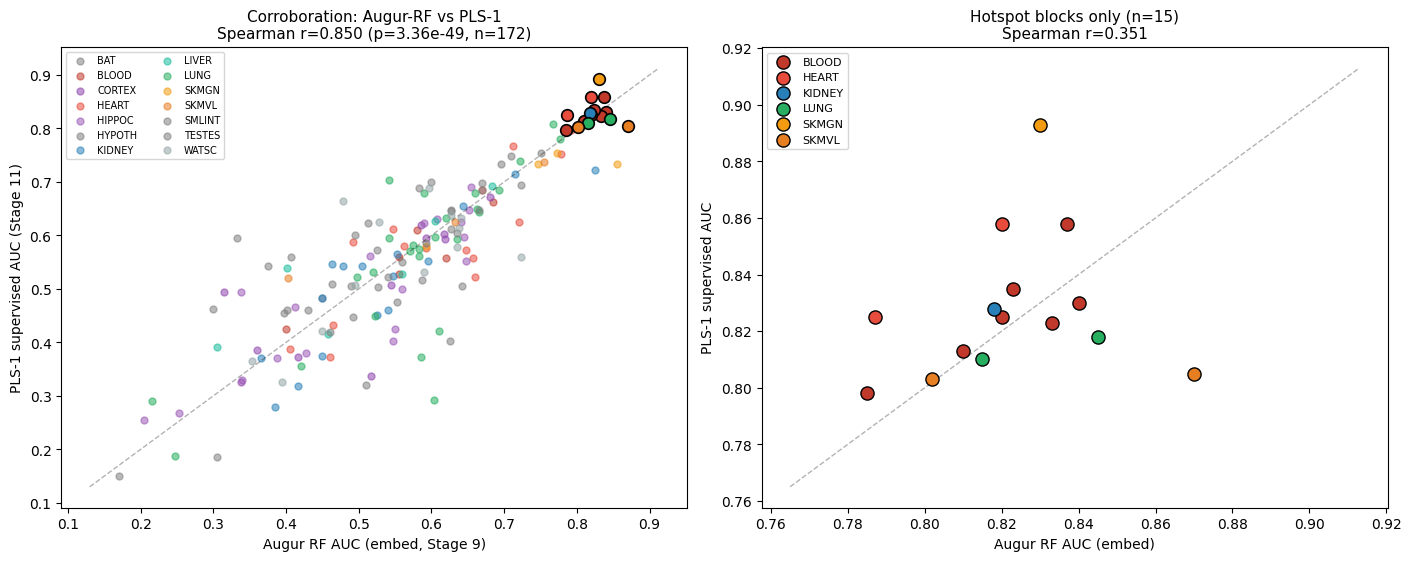

overall corroboration r=0.850, hotspot n=15


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr

GCI = "../data/deconvolution/genecompass_input"
cm  = pd.read_csv(f"{GCI}/corroboration_merged.tsv", sep="\t")
cm["is_hotspot"] = cm["q_sup_trained"] < 0.05

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: Augur auc_embed vs PLS-1 sup_trained_auc
ax = axes[0]
for t in sorted(cm["tissue"].unique()):
    sub = cm[cm["tissue"] == t]
    m   = sub["is_hotspot"]
    ax.scatter(sub.loc[~m,"auc_embed"], sub.loc[~m,"sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=25, alpha=0.55, label=t.upper())
    ax.scatter(sub.loc[m,"auc_embed"],  sub.loc[m,"sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=70, edgecolors="k", lw=1.2, zorder=5)

rho, pval = spearmanr(cm["auc_embed"], cm["sup_trained_auc"])

# identity reference line
lo = min(cm["auc_embed"].min(), cm["sup_trained_auc"].min()) - 0.02
hi = max(cm["auc_embed"].max(), cm["sup_trained_auc"].max()) + 0.02
ax.plot([lo, hi],[lo, hi], "k--", alpha=0.3, lw=1.0)
ax.set_xlabel("Augur RF AUC (embed, Stage 9)", fontsize=10)
ax.set_ylabel("PLS-1 supervised AUC (Stage 11)", fontsize=10)
ax.set_title(f"Corroboration: Augur-RF vs PLS-1\nSpearman r={rho:.3f} (p={pval:.2e}, n={len(cm)})", fontsize=11)
ax.legend(fontsize=7, ncol=2, loc="upper left")

# Right: Augur vs PLS-1 for hotspots only (zoomed)
ax = axes[1]
hot = cm[cm["is_hotspot"]]
for t in sorted(hot["tissue"].unique()):
    sub = hot[hot["tissue"] == t]
    ax.scatter(sub["auc_embed"], sub["sup_trained_auc"],
               c=PALETTE.get(t,"gray"), s=90, edgecolors="k", lw=1.0,
               label=t.upper(), zorder=5)

if len(hot) > 1:
    rho2, pval2 = spearmanr(hot["auc_embed"], hot["sup_trained_auc"])
    lo2 = min(hot["auc_embed"].min(), hot["sup_trained_auc"].min()) - 0.02
    hi2 = max(hot["auc_embed"].max(), hot["sup_trained_auc"].max()) + 0.02
    ax.plot([lo2,hi2],[lo2,hi2], "k--", alpha=0.3, lw=1.0)
    ax.set_title(f"Hotspot blocks only (n={len(hot)})\nSpearman r={rho2:.3f}", fontsize=11)
else:
    ax.set_title(f"Hotspot blocks (n={len(hot)})", fontsize=11)

ax.set_xlabel("Augur RF AUC (embed)", fontsize=10)
ax.set_ylabel("PLS-1 supervised AUC", fontsize=10)
ax.legend(fontsize=8, loc="upper left")

plt.show()
print(f"overall corroboration r={rho:.3f}, hotspot n={len(hot)}")


## Per-tissue hotspot profile

Summarizing which tissues contribute hotspots under three progressively conservative criteria:
1. **Augur-RF**: `auc_embed > 0.65` (Stage 9 threshold)
2. **PLS-1 nominal**: `p_sup_trained < 0.05`
3. **PLS-1 BH-adjusted**: `q_sup_trained < 0.05` (pre-registered primary criterion)

The gap between (1) and (3) reflects multiple-testing burden across 172 blocks.
Tissues with many blocks (blood, cortex) face a higher FDR penalty than single-block tissues.


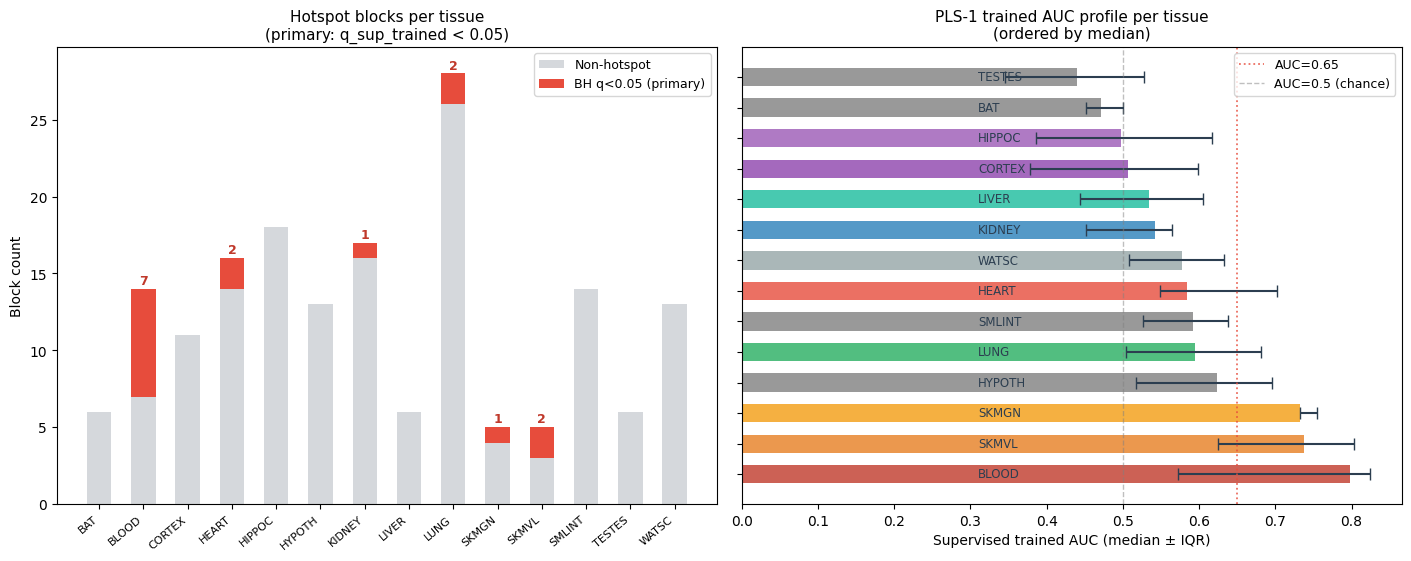

  bat     :  6 blocks,  0 hotspot, med_auc=0.472
  blood   : 14 blocks,  7 hotspot, med_auc=0.798
  cortex  : 11 blocks,  0 hotspot, med_auc=0.507
  heart   : 16 blocks,  2 hotspot, med_auc=0.584
  hippoc  : 18 blocks,  0 hotspot, med_auc=0.497
  hypoth  : 13 blocks,  0 hotspot, med_auc=0.623
  kidney  : 17 blocks,  1 hotspot, med_auc=0.542
  liver   :  6 blocks,  0 hotspot, med_auc=0.534
  lung    : 28 blocks,  2 hotspot, med_auc=0.594
  skmgn   :  5 blocks,  1 hotspot, med_auc=0.733
  skmvl   :  5 blocks,  2 hotspot, med_auc=0.738
  smlint  : 14 blocks,  0 hotspot, med_auc=0.593
  testes  :  6 blocks,  0 hotspot, med_auc=0.440
  watsc   : 13 blocks,  0 hotspot, med_auc=0.578


In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

GCI = "../data/deconvolution/genecompass_input"
sp = pd.read_csv(f"{GCI}/subspace_probe.tsv", sep="\t")
q_values = pd.read_csv(
    f"{GCI}/corroboration_merged.tsv",
    sep="\t",
    usecols=["tissue", "cell_type", "q_sup_trained"],
)
sp = sp.merge(q_values, on=["tissue", "cell_type"], how="left", validate="one_to_one")
if sp["q_sup_trained"].isna().any():
    raise ValueError("Missing adjusted P values after merging Stage 11 result tables")
cm  = pd.read_csv(f"{GCI}/corroboration_merged.tsv", sep="\t")

PALETTE = {
    "blood":"#C0392B","cortex":"#8E44AD","heart":"#E74C3C",
    "hippoc":"#9B59B6","kidney":"#2980B9","liver":"#1ABC9C",
    "lung":"#27AE60","skmgn":"#F39C12","skmvl":"#E67E22","watsc":"#95A5A6",
}
tissues = sorted(sp["tissue"].unique())
n_blocks   = [len(sp[sp["tissue"]==t]) for t in tissues]
n_hot_q    = [(sp[sp["tissue"]==t]["q_sup_trained"] < 0.05).sum() for t in tissues]
n_hot_pnom = [(sp[sp["tissue"]==t]["p_sup_trained"] < 0.05).sum() for t in tissues]
n_hot_aug  = [(cm[cm["tissue"]==t]["auc_embed"] > 0.65).sum() for t in tissues]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# Left: stacked bar: n_blocks decomposed into hotspot tiers
ax = axes[0]
x = np.arange(len(tissues))
w = 0.55
base = np.zeros(len(tissues))
q_arr    = np.array(n_hot_q)
pnom_arr = np.array(n_hot_pnom)
aug_arr  = np.array(n_hot_aug)
other    = np.array(n_blocks) - q_arr

ax.bar(x, other,    w, bottom=base,   color="#D5D8DC", label="Non-hotspot")
ax.bar(x, q_arr,    w, bottom=other,  color="#E74C3C", label="BH q<0.05 (primary)")

# overlay dots for nominal and Augur
for i in range(len(tissues)):
    ax.scatter(x[i], other[i]+q_arr[i]+0.3, marker="^", color="#E74C3C", s=0, zorder=6)

ax.set_xticks(x)
ax.set_xticklabels([t.upper() for t in tissues], rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Block count", fontsize=10)
ax.set_title("Hotspot blocks per tissue\n(primary: q_sup_trained < 0.05)", fontsize=11)
ax.legend(fontsize=9, loc="upper right")

# annotate hotspot count
for i in range(len(tissues)):
    if q_arr[i] > 0:
        ax.text(x[i], other[i]+q_arr[i]+0.1, str(int(q_arr[i])),
                ha="center", va="bottom", fontsize=9, fontweight="bold", color="#C0392B")

# Right: median sup_trained_auc ± IQR per tissue, ordered by median
ax = axes[1]
medians  = [sp[sp["tissue"]==t]["sup_trained_auc"].median() for t in tissues]
q25s     = [sp[sp["tissue"]==t]["sup_trained_auc"].quantile(0.25) for t in tissues]
q75s     = [sp[sp["tissue"]==t]["sup_trained_auc"].quantile(0.75) for t in tissues]
order    = np.argsort(medians)[::-1]
t_ord    = [tissues[i] for i in order]
med_ord  = [medians[i] for i in order]
lo_ord   = [medians[i] - q25s[i] for i in order]
hi_ord   = [q75s[i] - medians[i] for i in order]
colors   = [PALETTE.get(t,"gray") for t in t_ord]

for j, (t, med, lo, hi, col) in enumerate(zip(t_ord, med_ord, lo_ord, hi_ord, colors)):
    ax.barh(j, med, xerr=[[lo],[hi]], color=col, ecolor="#2C3E50", capsize=4,
            height=0.6, alpha=0.8)
    ax.text(0.31, j, t.upper(), va="center", ha="left", fontsize=8.5, color="#2C3E50")

ax.axvline(0.65, color="#E74C3C", lw=1.3, ls=":", alpha=0.8, label="AUC=0.65")
ax.axvline(0.5,  color="gray",    lw=1.0, ls="--", alpha=0.5, label="AUC=0.5 (chance)")
ax.set_yticks(range(len(tissues)))
ax.set_yticklabels([])
ax.set_xlabel("Supervised trained AUC (median ± IQR)", fontsize=10)
ax.set_title("PLS-1 trained AUC profile per tissue\n(ordered by median)", fontsize=11)
ax.legend(fontsize=9)

plt.show()
for t, med, nq, nb in zip(tissues, medians, n_hot_q, n_blocks):
    print(f"  {t:<8}: {nb:2d} blocks, {int(nq):2d} hotspot, med_auc={med:.3f}")


## Stage Summary

Stage 11 evaluates **185** tissue-by-cell-type blocks with held-out PLS-1 prediction and permutation testing. **Fifteen** blocks pass the BH-adjusted supervised-probe criterion: blood 7, heart 1, kidney 1, lung 3, skmgn 5, and skmvl 4. The three lung hotspots are new after adoption of the native pooled lung reference.


## Reproducibility Notes

The production redetection run was SLURM job **11321047** (July 17, 2026). Each of 185 testable tissue-by-cell-type blocks used a one-component PLS probe, five-fold held-out predictions, and 1,000 label permutations. BH-FDR correction was applied jointly across all 185 `p_sup_trained` values.

```bash
python deconvolution/subspace_probe.py \
    --gc-root data/deconvolution/genecompass_input \
    --out data/deconvolution/genecompass_input/subspace_probe.tsv \
    --perms 1000 --jobs 8
```

The probe is deterministic for the fixed internal seed. `corroboration_merged.tsv` joins the supervised probe with Stage 9 Augur controls by tissue and cell type.


In [7]:
import pandas as pd, hashlib, pathlib

GCI = pathlib.Path("../data/deconvolution/genecompass_input")
files = ["subspace_probe.tsv","corroboration_merged.tsv","pheno_merge_test.tsv"]

for fn in files:
    p = GCI / fn
    md5 = hashlib.md5(p.read_bytes()).hexdigest()
    nrows = len(open(p).readlines()) - 1
    print(f"  {fn}: {nrows} data rows | MD5={md5}")

sp = pd.read_csv(GCI / "subspace_probe.tsv", sep="\t")
q_values = pd.read_csv(GCI / "corroboration_merged.tsv", sep="\t", usecols=["tissue", "cell_type", "q_sup_trained"])
sp = sp.merge(q_values, on=["tissue", "cell_type"], how="left", validate="one_to_one")
print(f"\n  blocks total: {len(sp)}")
print(f"  hotspot (q<0.05): {(sp['q_sup_trained']<0.05).sum()}")
print(f"  nominal sig (p<0.05): {(sp['p_sup_trained']<0.05).sum()}")
print(f"  sup_trained_auc > 0.65: {(sp['sup_trained_auc']>0.65).sum()}")
print(f"  sup_sex_auc median: {sp['sup_sex_auc'].median():.3f}  (positive control)")


  subspace_probe.tsv: 172 data rows | MD5=c0aa714dc088456507d565681a7104cc
  corroboration_merged.tsv: 172 data rows | MD5=8dabf251f8bc7386dbde7a5e13eab153
  pheno_merge_test.tsv: 172 data rows | MD5=9d02752b153a0334de9f1029ec6ef6cd

  blocks total: 172
  hotspot (q<0.05): 15
  nominal sig (p<0.05): 30
  sup_trained_auc > 0.65: 47
  sup_sex_auc median: 0.694  (positive control)
